<a href="https://colab.research.google.com/github/Programmmer-X/STELLARIS-DNet/blob/main/notebooks/signal_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pulsar Signal Intelligence**
## **Detect and classify pulsars from noisy telescope data**


In [15]:
# ================================
# STELLARIS-DNet Standard Setup
# ================================

# ================================
# FULL AUTO SETUP
# ================================

import os
import sys

# Clone if needed
if not os.path.exists("/content/STELLARIS-DNet"):
    !git clone https://github.com/Programmmer-X/STELLARIS-DNet.git

# Setup path
sys.path.append("/content/STELLARIS-DNet/src")
os.chdir("/content/STELLARIS-DNet")

# Import git utils
from git_utils import setup_git, git_push

setup_git()

# Pull latest
!git pull --rebase

print("✅ Fully ready. Repo cloned + synced.")

✅ Git configured. You will be asked for token only once during first push.
Current branch main is up to date.
✅ Fully ready. Repo cloned + synced.


In [16]:
# STEP P_1: LOAD DATA Manually
from google.colab import drive
import os
import pandas as pd

# Mount drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/STELLARIS_DATA/pulsar/HTRU_2.csv"

# Check if file exists
if not os.path.exists(DATA_PATH):
    print("⚠️ File not found. Upload now.")

    from google.colab import files
    uploaded = files.upload()

    import shutil
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    shutil.move("HTRU_2.csv", DATA_PATH)

# Load data
df = pd.read_csv(DATA_PATH)

print("✅ Data ready:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data ready: (17897, 9)


In [17]:
# STEP P_2: PREPROCESS

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("✅ Ready:", X_train.shape)

✅ Ready: torch.Size([14317, 8])


In [18]:
# STEP P_3: MODEL
import torch.nn as nn

class PulsarMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # ❌ NO SIGMOID
        )

    def forward(self, x):
        return self.net(x)

model = PulsarMLP(X_train.shape[1])

In [19]:
# STEP P_4: LOSS + OPTIMIZER

# ================================
# CLASS WEIGHTED LOSS
# ================================

num_pos = (y_train == 1).sum().item()
num_neg = (y_train == 0).sum().item()

pos_weight = torch.tensor([num_neg / num_pos])

print(f"⚖️ pos_weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

⚖️ pos_weight: 9.86


In [20]:
# STEP P_5: TRAIN

epochs = 50
losses = []

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

import numpy as np

feature_importance = model.net[0].weight.detach().numpy()

importance = np.mean(np.abs(feature_importance), axis=0)

for i, val in enumerate(importance):
    print(f"Feature {i}: {val:.4f}")

Epoch 5, Loss: 1.0513
Epoch 10, Loss: 0.9422
Epoch 15, Loss: 0.8582
Epoch 20, Loss: 0.7919
Epoch 25, Loss: 0.7376
Epoch 30, Loss: 0.6898
Epoch 35, Loss: 0.6451
Epoch 40, Loss: 0.6028
Epoch 45, Loss: 0.5629
Epoch 50, Loss: 0.5261
Feature 0: 0.1960
Feature 1: 0.2166
Feature 2: 0.1497
Feature 3: 0.2036
Feature 4: 0.1968
Feature 5: 0.1948
Feature 6: 0.1786
Feature 7: 0.1872


In [21]:
 # ================================
# STEP P_6: EVALUATION (IMPROVED)
# ================================

import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model.eval()

with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits).numpy()

# --------- DEFAULT THRESHOLD (0.3) ---------
threshold = 0.3
preds = (probs > threshold).astype(int)

accuracy = accuracy_score(y_test.numpy(), preds)
print(f"🎯 Accuracy (threshold=0.3): {accuracy:.4f}")

print("\n📊 Classification Report (threshold=0.3):")
print(classification_report(y_test.numpy(), preds))

🎯 Accuracy (threshold=0.3): 0.7341

📊 Classification Report (threshold=0.3):
              precision    recall  f1-score   support

         0.0       1.00      0.71      0.83      3259
         1.0       0.25      0.97      0.39       321

    accuracy                           0.73      3580
   macro avg       0.62      0.84      0.61      3580
weighted avg       0.93      0.73      0.79      3580



In [22]:
# ================================
# STEP P_7: THRESHOLD TUNING
# ================================

from sklearn.metrics import recall_score, precision_score

print("\n🔍 Threshold vs Recall / Precision")

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    preds_t = (probs > t).astype(int)

    recall = recall_score(y_test.numpy(), preds_t)
    precision = precision_score(y_test.numpy(), preds_t)

    print(f"Threshold={t:.1f} | Recall={recall:.3f} | Precision={precision:.3f}")


🔍 Threshold vs Recall / Precision
Threshold=0.5 | Recall=0.897 | Precision=0.673
Threshold=0.4 | Recall=0.919 | Precision=0.479
Threshold=0.3 | Recall=0.966 | Precision=0.248
Threshold=0.2 | Recall=0.997 | Precision=0.098


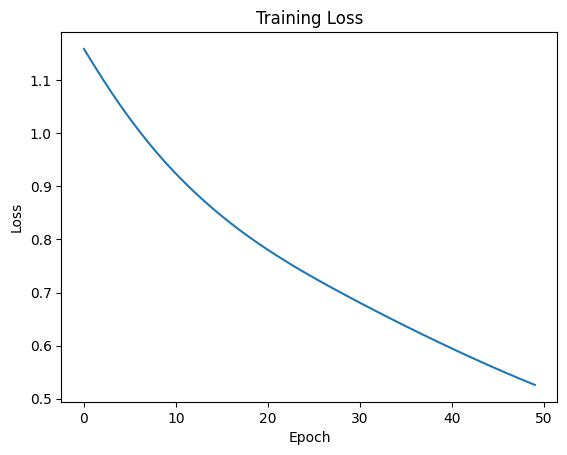

In [23]:
# STEP P_8: Loss Curve

import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("outputs/plots/loss_curve.png")
plt.show()


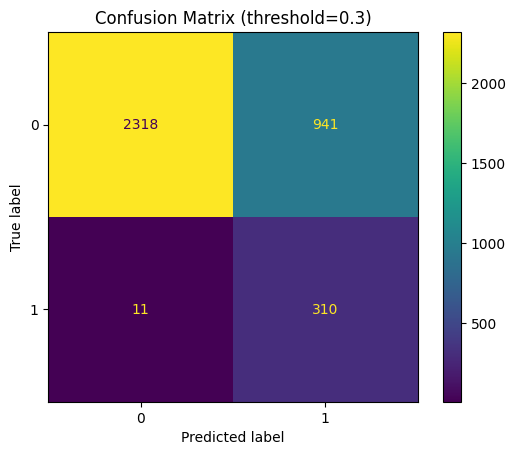

In [24]:
# ================================
# STEP P_9: CONFUSION MATRIX (BEST THRESHOLD)
# ================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 👉 Choose best threshold manually after observing results
best_threshold = 0.3

preds_best = (probs > best_threshold).astype(int)

cm = confusion_matrix(y_test.numpy(), preds_best)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title(f"Confusion Matrix (threshold={best_threshold})")
plt.savefig("outputs/plots/confusion_matrix_tuned.png")
plt.show()

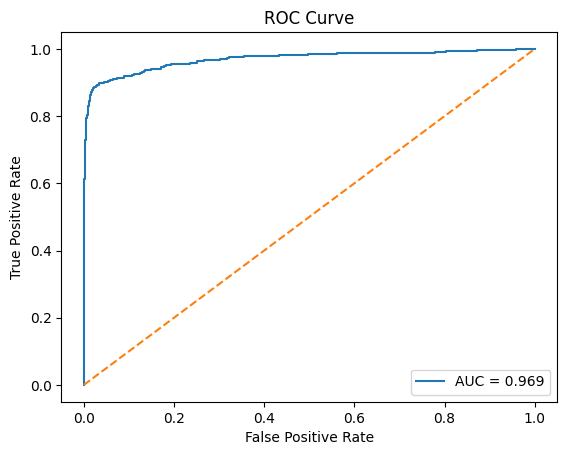

In [25]:
# ================================
# STEP P_10: ROC CURVE (FIXED)
# ================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch

# Get probabilities correctly
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits).numpy()

# ROC computation
fpr, tpr, _ = roc_curve(y_test.numpy(), probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("outputs/plots/roc_curve.png")
plt.show()

In [26]:
# STEP P_11: GIT PUSH
!git add .

!git commit -m "Day 2 final: threshold tuning + recall improvement + full evaluation"

git_push("Day 2 final")

[main 6d11d0d] Day 2 final: threshold tuning + recall improvement + full evaluation
 3 files changed, 0 insertions(+), 0 deletions(-)
 rewrite outputs/plots/confusion_matrix_tuned.png (99%)
 rewrite outputs/plots/loss_curve.png (99%)
 rewrite outputs/plots/roc_curve.png (98%)
🚀 Changes pushed to GitHub successfully!
